In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2


/tmp/ipykernel_2984955/1024337592.py:6: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/spandey/venv_gm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
from __future__ import print_function
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os,sys
import hmvec as hm # Git clone and pip install as in readme from github.com/msyriac/hmvec
import numpy as np
import time

zgalaxy = 0.01 # delta-function lens population
zsource = 1.0 # delta-function source population
ngal = 1e-4 # number density of lenses per mpc3 (to solve for stellar mass threshold in HOD)

# We set up the grid to integrate on
zmax = zsource + 1
numzs = 20
zs = np.linspace(0.01,zmax,numzs) # redshifts
ms = np.geomspace(2e10,1e17,100) # masses
ks = np.geomspace(1e-4,100,101) # wavenumbers

# Initialize halo model
hcos = hm.HaloModel(zs,ks,ms=ms)
# We add an HOD which should be CMASS-like at z=zgalaxy
hcos.add_hod("g",ngal=ngal+zs*0.,corr="max")
print("Galaxy bias at zgalaxy=",zgalaxy, " is ",interp1d(zs,hcos.hods['g']['bg'])(zgalaxy))
# We add a gas profile
a = time.time()
hcos.add_battaglia_profile("electron",family="AGN",xmax=50,nxs=30000)
b = time.time()-a
print(f"Profile took {b} seconds.")

"""
Galaxy-galaxy lensing
"""
Pgn = hcos.get_power("g","nfw",verbose=False)
Pge = hcos.get_power("g","electron",verbose=False )
Pgm = hcos.total_matter_galaxy_power_spectrum(Pgn,Pge)



Bisection search converged in  19  iterations.
Galaxy bias at zgalaxy= 0.01  is  1.5229855726989676


/mnt/ceph/users/spandey/hmvec/hmvec/hmvec.py:719: RuntimeWarning: invalid value encountered in divide
  ret = Ns**2./Nc
/mnt/ceph/users/spandey/hmvec/hmvec/fft.py:91: RuntimeWarning: invalid value encountered in divide
  uk = ukts/kts[None,None,:]/mnorm[...,None]


Profile took 3.7324657440185547 seconds.


In [37]:
ns=hcos.params['ns']
Om=(hcos.params['omch2']+hcos.params['ombh2'])/hcos.h**2
Ob=(hcos.params['ombh2'])/hcos.h**2
h=hcos.h
import camb
lmax = 20000
pars = camb.CAMBparams(max_l=lmax)
pars.set_cosmology(H0=h*100,
                ombh2=Ob * h ** 2,
                omch2=(Om - Ob) * h ** 2,
                mnu=0.0,
                omk=0,
                )
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
As_fid = hcos.params['As']
pars.InitPower.set_params(As=As_fid, ns=ns, r=0)
redshifts_all = np.linspace(0, 2, 100)
pars.set_matter_power(redshifts=redshifts_all, kmax=1000)
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
sigma8_all = results.get_sigma8()
sigma8_camb = sigma8_all[-1]

Cl_cmb = results.get_cmb_power_spectra(pars, lmax=lmax, CMB_unit='muK', raw_cl=True)['total'][:,0]
ell_cmb = np.arange(Cl_cmb.shape[0])


Note: redshifts have been re-sorted (earliest first)


In [38]:
# fsigma8 = results.get_fsigma8()
# fz = fsigma8/sigma8_all
# print(fz, fsigma8)
# sigma8_camb
# sigma8_all
# results.redshifts
# np.array(pars.Transfer.PK_redshifts)
# print(z_all)



In [39]:
df = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/notebooks/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt')
# df.shape
ell_noise = df[:,0]
Nell_T = df[:,1]
Nell_interp = interp1d(np.log(ell_noise),np.log(np.clip(Nell_T, 1e-10, 1e10)),bounds_error=False,fill_value='extrapolate')
Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))
Nell_T[0] = Nell_T[1]


Cl_tot = Cl_cmb + Nell_T


/tmp/ipykernel_2984955/395379375.py:6: RuntimeWarning: divide by zero encountered in log
  Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))


In [40]:
# pl.figure()
# pl.loglog(ell_cmb,Cl_cmb)
# pl.loglog(ell_cmb,Nell_T)



In [41]:
# df = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/notebooks/desi_lrg_nz.txt')
# df.shape
# zcen, ngal_mpc3 = df[:,0], df[:,1]

# chi = results.get_comoving_radial_distance(zcen)
zedges = np.array([0.4, 0.6, 0.8,1.1])
Ngals_bins = np.array([506905, 771875, 859824])
Ngals_tot = np.sum(Ngals_bins)
Vol_Gpc3 = np.array([2.6, 4.0, 5.0])
z_cens = np.array([0.51, 0.71, 0.92])
Vol_Mpc3 = Vol_Gpc3*1e9
ngal_mpc3 = Ngals_bins/Vol_Mpc3
# fsky = 5840/41000
# vols_gpc3,ngals_mpc3,zcents,bgs,snrs,totsnr = ksz.get_ksz_snr_survey(zcen, ngal_mpc3, zedges, Cl_tot, fsky, Ngals_tot)



In [42]:
from hmvec import ksz
ksz_obj = ksz.kSZ(z_cens, Vol_Gpc3, ngal_mpc3,engine='camb')




/mnt/ceph/users/spandey/hmvec/hmvec/fft.py:91: RuntimeWarning: invalid value encountered in divide
  uk = ukts/kts[None,None,:]/mnorm[...,None]
/mnt/ceph/users/spandey/hmvec/hmvec/hmvec.py:719: RuntimeWarning: invalid value encountered in divide
  ret = Ns**2./Nc
/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:170: UserWarning: Using equal k_min at each z, despite different volumes at each z
  warnings.warn('Using equal k_min at each z, despite different volumes at each z')


Bisection search converged in  19  iterations.
Note: redshifts have been re-sorted (earliest first)


In [51]:
# len(z_cens),len(Vol_Gpc3), len(ngal_mpc3)
# ks_bin_edges = np.logspace(-1, 0.5, 20)
# get bin edges from ks array:
logkcens = np.log(ks)
dlogk = logkcens[1]-logkcens[0]
logk_edges = logkcens - dlogk/2
logk_edges = np.append(logk_edges,logk_edges[-1]+dlogk)
ks_bin_edges = np.exp(logk_edges)
Pge_err_z0 = ksz_obj.Pge_err(0,ks_bin_edges,Cl_tot)
Pge_err_z1 = ksz_obj.Pge_err(0,ks_bin_edges,Cl_tot)
Pge_err_z2 = ksz_obj.Pge_err(0,ks_bin_edges,Cl_tot)


/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:56: RuntimeWarning: divide by zero encountered in power
  return (volume * kstar**2 / 12 / np.pi**3 / chistar**2. * pgv_int * np.asarray(ints))**(-0.5)


In [ ]:
# Pge_err
# ks
# ks_bin_edges
# len(Pge_err), len(ks_bin_edges), len(ks)
# np.log(ks)



5

(0.1, 10)

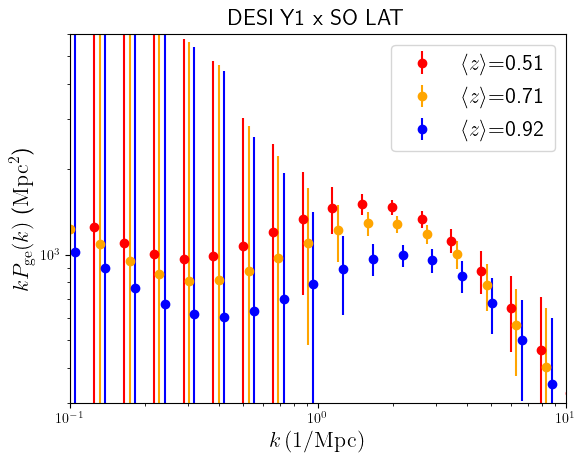

In [57]:
pl.rc('text', usetex=True)
# make a three panel plot, plotting all the theta_ej curves for for gty_out_thetaej[:,3,:], xip_out_thetaej[:,3,3,:], xim_out_thetaej[:,3,3,:]
# draw theta_ej curves from a colormap
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
# create a normalize object the scales the input Mc0 value to the range [0,1]
# norm = Normalize(vmin=(theta_ej_array).min(), vmax=(theta_ej_array).max())
# analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))
dsfac = 2
indz = np.argmin(np.abs(zs - z_cens[0]))
pl.errorbar(0.95*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z0)[::dsfac],label=r'$\langle z \rangle$=0.51', color='red', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[1]))
pl.errorbar(ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z1)[::dsfac],label=r'$\langle z \rangle$=0.71', color='orange', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[2]))
pl.errorbar(1.05*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z2)[::dsfac],label=r'$\langle z \rangle$=0.92', color='blue', ls='', marker='o')

pl.title('DESI Y1 x SO LAT', fontsize=16)
pl.ylim(3e2, 6e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 10)
# sm = ScalarMappable(cmap=cmap, norm=norm)
# the array is not used in this case, but normally the values used for the colormap are passed here
# sm.set_array([])
# add the colorbar to the figure
# cbar = pl.colorbar(sm, ax=pl.gcf().get_axes(), orientation='vertical', fraction=0.05, pad=0.01)
# cbar.set_label(r'$\theta_{\rm ej, 0}$', fontsize=16, rotation=270, labelpad=20)
# cbar.ax.tick_params(labelsize=15)





In [ ]:
from hmvec import ksz
# volumes_gpc3 = 5
# ngals_mpc3 = 1
# ells = np.arange(len(Cl_cmb))
# hksz = ksz.kSZ(zs,volumes_gpc3,ngals_mpc3, ks=ks,ms=ms)
kSZ_auto = ksz.get_ksz_auto_signal_mafry(ell_cmb, Vol_Gpc3, z_cens, ngal_mpc3)


/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:38: SyntaxWarning: invalid escape sequence '\i'
  """
/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:436: SyntaxWarning: invalid escape sequence '\i'
  """
/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:473: SyntaxWarning: invalid escape sequence '\e'
  """
/mnt/ceph/users/spandey/hmvec/hmvec/ksz.py:665: SyntaxWarning: invalid escape sequence '\e'
  """


AssertionError: 

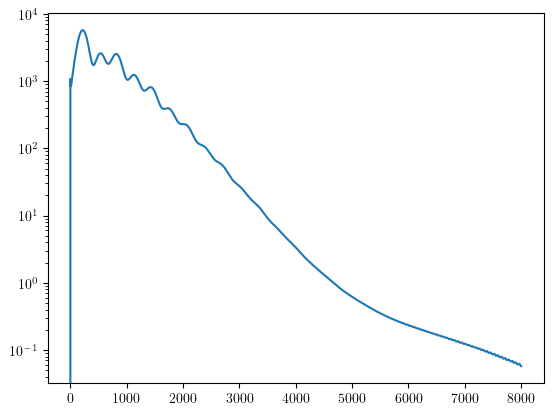

In [12]:
# Cl_cmb.shape
ell = np.arange(len(Cl_cmb))
fac = ell*(ell+1)/(2*np.pi)
pl.figure()
pl.plot(ell,fac*Cl_cmb)
pl.yscale('log')




In [107]:
# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.0
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.05
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 1.4
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.0
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 1.1
sim_params_dict['nu_z'] = 0.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

hod_params_dict = {}
hod_params_dict['logMmin'] = 12.88
hod_params_dict['sigma_logM'] = 0.2
hod_params_dict['logM0'] = 12.88
hod_params_dict['logM1'] = 14.0
hod_params_dict['alpha'] = 1.3
sim_params_dict['hod_params'] = hod_params_dict
sim_params_dict['hod_type'] = 'Zheng05'


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 12, 48
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 0.002, 2
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 1.0, 10
# halo_params_dict['z_array'] = np.array([1e-3, 0.5, 1.0])
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 3.0, 20
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 2.0, 20
# halo_params_dict['z_array'] = np.array([1e-3])
# halo_params_dict['z_array'] = np.array([0.5])
# halo_params_dict['z_array'] = np.array([1.0])
# halo_params_dict['nz'] = len(halo_params_dict['z_array'])
# halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 12.0, 15.5, 20
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 72
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 1.0
lmax = 60000.0
fac = 3
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
# df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
# nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict = {}
analysis_dict['nz_info_dict'] = nz_info_dict
analysis_dict['do_sheary'] = True
analysis_dict['do_shear2pt'] = True
analysis_dict['do_yy'] = True

analysis_dict['fsky_yy'] = 0.1
analysis_dict['fsky_ky'] = 0.1
analysis_dict['fsky_kk'] = 0.1
analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = False
# analysis_dict['stats_for_cov'] = ['ky']
analysis_dict['stats_for_cov'] = ['ky', 'kk']
analysis_dict['analysis_coords'] = 'real'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = [0.2724, 0.2724, 0.2724, 0.2724]
# analysis_dict['neff_arcmin2_SN_bins'] = [1.7971, 1.5521, 1.5967, 1.0979]

analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(nz_info_dict['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(nz_info_dict['nbins'])






In [114]:
from setup_power_spectra import setup_power_BCMP
import copy
theta_ej_array = np.linspace(1.0, 2.0, 8)
Pge_all = {}
for j, theta_ej in enumerate(theta_ej_array):
    print(j)
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    sim_params_dict_vary['theta_ej_0'] = theta_ej
    setup_power_BCMP_test = setup_power_BCMP(sim_params_dict_vary, halo_params_dict, analysis_dict, num_points_trapz_int=64, verbose_time=True)
    Pge_all[j] = setup_power_BCMP_test.Pge_tot_kz_mat[:,0]



0
Time taken to calculate BCMP profile:  5.99727463722229  seconds
Time taken to setup Pk:  2.5109927654266357
Time taken to setup HMF:  5.736354112625122
1
Time taken to calculate BCMP profile:  6.087428331375122  seconds
Time taken to setup Pk:  2.346438407897949
Time taken to setup HMF:  5.35601806640625
2
Time taken to calculate BCMP profile:  6.142686367034912  seconds
Time taken to setup Pk:  2.3521711826324463
Time taken to setup HMF:  8.405919790267944
3
Time taken to calculate BCMP profile:  6.127694129943848  seconds
Time taken to setup Pk:  2.370722532272339
Time taken to setup HMF:  5.3527679443359375
4
Time taken to calculate BCMP profile:  6.4968931674957275  seconds
Time taken to setup Pk:  2.1392459869384766
Time taken to setup HMF:  5.659941673278809
5
Time taken to calculate BCMP profile:  5.896625995635986  seconds
Time taken to setup Pk:  2.4535374641418457
Time taken to setup HMF:  5.692966461181641
6
Time taken to calculate BCMP profile:  8.63790512084961  seconds

In [109]:
# setup_power_BCMP_test.uk_ne[0,:,0]
setup_power_BCMP_test.z_array, setup_power_BCMP_test.bg_kz_mat[0,:]
# setup_power_BCMP_test.z_array


(Array([0.01      , 0.11473684, 0.21947368, 0.32421053, 0.42894737,
        0.53368421, 0.63842105, 0.74315789, 0.84789474, 0.95263158,
        1.05736842, 1.16210526, 1.26684211, 1.37157895, 1.47631579,
        1.58105263, 1.68578947, 1.79052632, 1.89526316, 2.        ],      dtype=float64),
 Array([1.53226046, 1.59441271, 1.66231736, 1.73703394, 1.8217744 ,
        1.91410893, 2.01533096, 2.12764701, 2.24914776, 2.37925549,
        2.51854797, 2.66640943, 2.82250918, 2.98763055, 3.16096239,
        3.3423926 , 3.53091259, 3.72784073, 3.93225648, 4.14379061],      dtype=float64))

/tmp/ipykernel_1579331/3632242555.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')  # or any other colormap you like


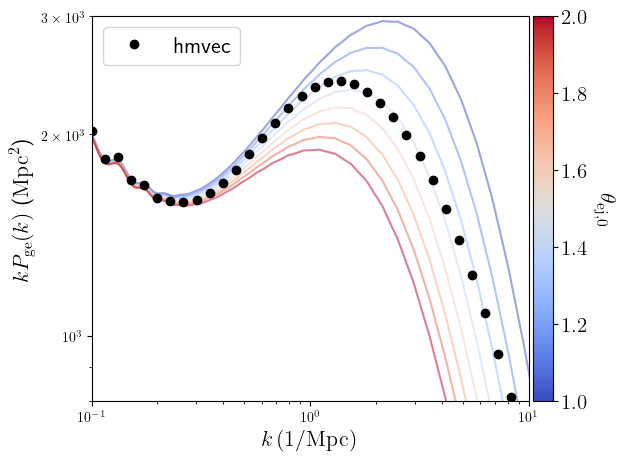

In [117]:
pl.rc('text', usetex=True)
# make a three panel plot, plotting all the theta_ej curves for for gty_out_thetaej[:,3,:], xip_out_thetaej[:,3,3,:], xim_out_thetaej[:,3,3,:]
# draw theta_ej curves from a colormap
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

cmap = cm.get_cmap('coolwarm')  # or any other colormap you like
# create a normalize object the scales the input Mc0 value to the range [0,1]
norm = Normalize(vmin=(theta_ej_array).min(), vmax=(theta_ej_array).max())
# analysis_dict_vary['angles_data_array'] = jnp.logspace(np.log10(0.5), np.log10(100), fac_th * len(theta_data))

pl.figure(figsize=(6,5))
for j, theta_ej in enumerate(theta_ej_array):
    color = cmap(norm((theta_ej_array[j])))
    pl.plot(setup_power_BCMP_test.k*h, (setup_power_BCMP_test.k)*Pge_all[j]*(1/h**2), alpha=0.5, color=color)

pl.plot(ks[::10],(ks*Pge[0])[::10],label='hmvec', color='black', ls='', marker='o')

pl.ylim(8e2, 3e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 10)
sm = ScalarMappable(cmap=cmap, norm=norm)
# the array is not used in this case, but normally the values used for the colormap are passed here
sm.set_array([])
# add the colorbar to the figure
cbar = pl.colorbar(sm, ax=pl.gcf().get_axes(), orientation='vertical', fraction=0.05, pad=0.01)
cbar.set_label(r'$\theta_{\rm ej, 0}$', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=15)


(0.1, 10)

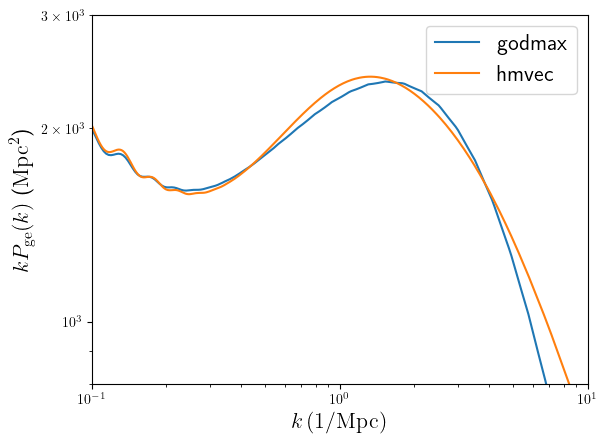

In [110]:
h = cosmo_params_dict['H0']/100
pl.figure()
pl.plot(setup_power_BCMP_test.k*h, (setup_power_BCMP_test.k)*setup_power_BCMP_test.Pge_tot_kz_mat[:,0]*(1/h**2),label='godmax')
pl.plot(ks,ks*Pge[0],label='hmvec')
# pl.plot(setup_power_BCMP_test.k*h, (setup_power_BCMP_test.k)*setup_power_BCMP_test.Pge_tot_kz_mat[:,8])
# pl.plot(setup_power_BCMP_test.k, (setup_power_BCMP_test.k)*setup_power_BCMP_test.Pge_1h_mat[:,0])
# pl.plot(setup_power_BCMP_test.k, (setup_power_BCMP_test.k)*setup_power_BCMP_test.Pge_2h_mat[:,0])

# pl.plot(setup_power_BCMP_test.k, (setup_power_BCMP_test.k)*setup_power_BCMP_test.Pge_2h_mat[:,0])
pl.ylim(8e2, 3e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 10)
# pl.title(r'$z=0$')



ModuleNotFoundError: No module named 'hmvec'

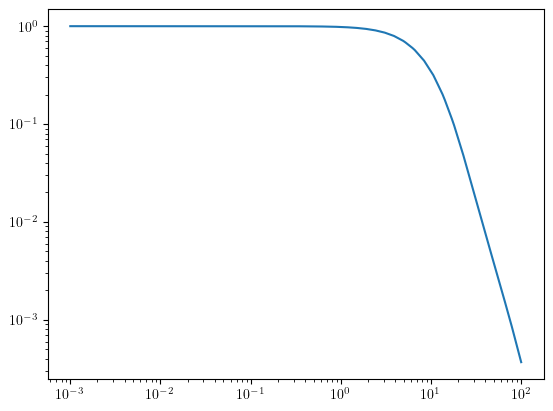

In [17]:
pl.figure()
pl.plot(setup_power_BCMP_test.k, setup_power_BCMP_test.uk_ne[:,0,8])
pl.xscale('log')
pl.yscale('log')
